# DoWhy Tutorial 08: Refuters, Placebos, Negative Controls, And Sensitivity

The earlier tutorials built causal estimates from explicit graphs and estimators. This notebook asks the next question: **how hard should we try to break the result?**

DoWhy calls many of these checks **refuters**. A refuter perturbs the analysis in a targeted way and asks whether the original estimate behaves as expected. For example, if we replace the real treatment with a placebo treatment, the estimated effect should move toward zero. If we rerun the analysis on random subsets of the data, the effect should stay reasonably stable.

This notebook combines three kinds of credibility checks:

- **DoWhy refuters:** random common cause, placebo treatment, data subset, and bootstrap refuters.
- **Negative controls:** variables that should not be affected by the treatment.
- **Sensitivity analysis:** hypothetical hidden confounding strong enough to move the estimate.

The important tone is humility. Passing these checks does not prove a causal effect. Failing them tells us where the design needs more work.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain what a causal refuter is and what it is not.
- Run common DoWhy refuters on a fitted causal estimate.
- Convert refuter outputs into a compact comparison table.
- Use negative-control outcomes and placebo exposures as falsification checks.
- Diagnose whether a result is stable to sample perturbations and measurement noise.
- Run a direct unobserved-confounding sensitivity grid.
- Write a short credibility summary that separates evidence, assumptions, and remaining risk.

## What Refuters Can And Cannot Do

A refuter is a stress test. It asks whether an estimate behaves sensibly when the analysis is changed in a way that has a known expected pattern.

Examples:

- A **placebo treatment** should have no effect.
- A **random extra common cause** should not meaningfully change the estimate.
- A **data subset** should produce a similar estimate if the result is not driven by a small slice of rows.
- A **bootstrap perturbation** should produce estimates near the original value if the result is stable.

These checks are valuable, but they are not magic. A study can pass several refuters and still be biased by an unmeasured confounder, a bad graph, interference, post-treatment conditioning, measurement error, or poor overlap. Treat refuters as evidence that strengthens or weakens confidence, not as a final stamp of truth.

## Setup

The setup cell imports the libraries, applies warning filters, creates output folders, and fixes plotting defaults. The environment variable for Matplotlib keeps notebook execution quiet in shared environments where the default cache directory may not be writable.

In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import dowhy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from dowhy import CausalModel
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebooks" / "tutorials" / "dowhy").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = Path.cwd()

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(808)

print(f"DoWhy version: {dowhy.__version__}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Figure output directory: {FIGURE_DIR}")
print(f"Table output directory: {TABLE_DIR}")

DoWhy version: 0.14
Notebook directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy
Figure output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/figures
Table output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/tables


The notebook is ready once the DoWhy version and output directories print. All saved artifacts from this notebook use a `08_` prefix.

## Refuter Roadmap

The table below gives a quick map of the checks we will run. Each check has a different purpose, so the final credibility summary should mention the pattern across checks instead of relying on one number.

In [2]:
refuter_roadmap = pd.DataFrame(
    [
        {
            "check": "Random common cause refuter",
            "question": "Does adding a random covariate leave the estimate mostly unchanged?",
            "expected pattern": "The new effect should stay close to the original estimate.",
        },
        {
            "check": "Placebo treatment refuter",
            "question": "Does a fake treatment produce a near-zero effect?",
            "expected pattern": "The placebo effect should be close to zero.",
        },
        {
            "check": "Data subset refuter",
            "question": "Is the estimate stable across random subsets?",
            "expected pattern": "The subset estimate should stay close to the original estimate.",
        },
        {
            "check": "Bootstrap refuter",
            "question": "Is the estimate stable under resampling and small covariate perturbations?",
            "expected pattern": "The bootstrap estimate should stay close to the original estimate.",
        },
        {
            "check": "Negative-control outcome",
            "question": "Does treatment appear to affect an outcome it cannot plausibly affect?",
            "expected pattern": "The adjusted treatment coefficient should be near zero.",
        },
        {
            "check": "Hidden-confounding sensitivity",
            "question": "How strong would an unobserved common cause need to be to move the result?",
            "expected pattern": "The estimate should degrade gradually as hypothetical confounding gets stronger.",
        },
    ]
)

refuter_roadmap.to_csv(TABLE_DIR / "08_refuter_roadmap.csv", index=False)
display(refuter_roadmap)

,check,question,expected pattern
0,Random common cause refuter,Does adding a random covariate leave the estim...,The new effect should stay close to the origin...
1,Placebo treatment refuter,Does a fake treatment produce a near-zero effect?,The placebo effect should be close to zero.
2,Data subset refuter,Is the estimate stable across random subsets?,The subset estimate should stay close to the o...
3,Bootstrap refuter,Is the estimate stable under resampling and sm...,The bootstrap estimate should stay close to th...
4,Negative-control outcome,Does treatment appear to affect an outcome it ...,The adjusted treatment coefficient should be n...
5,Hidden-confounding sensitivity,How strong would an unobserved common cause ne...,The estimate should degrade gradually as hypot...


The roadmap frames this notebook as a sequence of falsification and stability checks. The best analyses explain why each check is relevant to the causal risk at hand.

## Simulate A Teaching Dataset

We will simulate a clean observational setting where the true treatment effect is known. The treatment is `recommendation_exposure`, the outcome is `weekly_value`, and all important confounders are observed.

The dataset also includes a `negative_control_outcome`. This outcome is affected by the same pre-treatment variables that influence treatment assignment, but it is not affected by the treatment. That makes it useful for detecting residual confounding.

In [3]:
def make_refuter_teaching_data(n=4_000, seed=808):
    local_rng = np.random.default_rng(seed)

    pre_activity = local_rng.normal(loc=0.0, scale=1.0, size=n)
    power_segment = local_rng.binomial(n=1, p=0.40, size=n)
    account_age = local_rng.gamma(shape=4.0, scale=8.0, size=n)
    account_age_z = (account_age - account_age.mean()) / account_age.std()
    seasonality_score = local_rng.normal(loc=0.0, scale=1.0, size=n)

    treatment_logit = (
        -0.25
        + 0.70 * pre_activity
        + 0.45 * power_segment
        + 0.25 * account_age_z
        + 0.30 * seasonality_score
    )
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    recommendation_exposure = local_rng.binomial(n=1, p=treatment_probability)

    true_effect = 1.20
    weekly_value = (
        4.00
        + true_effect * recommendation_exposure
        + 0.85 * pre_activity
        + 0.75 * power_segment
        + 0.35 * account_age_z
        + 0.45 * seasonality_score
        + local_rng.normal(scale=1.00, size=n)
    )

    negative_control_outcome = (
        2.00
        + 0.75 * pre_activity
        + 0.55 * power_segment
        + 0.25 * account_age_z
        + 0.30 * seasonality_score
        + local_rng.normal(scale=1.00, size=n)
    )

    return pd.DataFrame(
        {
            "recommendation_exposure": recommendation_exposure,
            "weekly_value": weekly_value,
            "pre_activity": pre_activity,
            "power_segment": power_segment,
            "account_age_z": account_age_z,
            "seasonality_score": seasonality_score,
            "negative_control_outcome": negative_control_outcome,
            "treatment_probability": treatment_probability,
        }
    ), true_effect

refuter_df, true_effect = make_refuter_teaching_data()

print(f"Rows: {len(refuter_df):,}")
print(f"Observed exposure rate: {refuter_df['recommendation_exposure'].mean():.3f}")
print(f"True treatment effect used in the simulation: {true_effect:.2f}")
display(refuter_df.head())

Rows: 4,000
Observed exposure rate: 0.493
True treatment effect used in the simulation: 1.20


,recommendation_exposure,weekly_value,pre_activity,power_segment,account_age_z,seasonality_score,negative_control_outcome,treatment_probability
0,1,4.3964,-0.9931,0,-0.6166,-0.7996,1.6854,0.2076
1,1,5.4087,0.7585,0,0.6759,0.2998,2.6646,0.6318
2,1,4.8436,0.6035,0,0.2772,-1.3627,2.9589,0.4583
3,0,1.8962,-0.9142,0,0.0959,-0.5155,1.7911,0.2649
4,0,3.5121,0.0254,1,-0.4859,0.3905,3.4602,0.5532


The data look like a normal observational dataset, but we also know the truth because the data were simulated. That lets us tell the difference between a refuter that behaves as expected and a refuter that signals trouble.

## Data Field Guide

This table documents the columns and their roles. Refuter notebooks benefit from explicit field definitions because placebo and negative-control checks are easy to misunderstand if the variable roles are blurry.

In [4]:
field_guide = pd.DataFrame(
    [
        {
            "column": "recommendation_exposure",
            "role": "treatment",
            "description": "Binary indicator for whether the unit received the exposure.",
        },
        {
            "column": "weekly_value",
            "role": "outcome",
            "description": "Post-treatment outcome affected by exposure and pre-treatment confounders.",
        },
        {
            "column": "pre_activity",
            "role": "confounder",
            "description": "Pre-treatment activity score affecting both exposure and weekly value.",
        },
        {
            "column": "power_segment",
            "role": "confounder",
            "description": "Binary segment flag affecting both exposure and weekly value.",
        },
        {
            "column": "account_age_z",
            "role": "confounder",
            "description": "Standardized account age affecting both exposure and weekly value.",
        },
        {
            "column": "seasonality_score",
            "role": "confounder",
            "description": "Pre-treatment timing score affecting both exposure and weekly value.",
        },
        {
            "column": "negative_control_outcome",
            "role": "negative-control outcome",
            "description": "Outcome-like variable affected by confounders but not by the treatment.",
        },
        {
            "column": "treatment_probability",
            "role": "simulation diagnostic",
            "description": "True exposure probability used by the simulator; usually unknown in real observational data.",
        },
    ]
)

field_guide.to_csv(TABLE_DIR / "08_field_guide.csv", index=False)
display(field_guide)

,column,role,description
0,recommendation_exposure,treatment,Binary indicator for whether the unit received...
1,weekly_value,outcome,Post-treatment outcome affected by exposure an...
2,pre_activity,confounder,Pre-treatment activity score affecting both ex...
3,power_segment,confounder,Binary segment flag affecting both exposure an...
4,account_age_z,confounder,Standardized account age affecting both exposu...
5,seasonality_score,confounder,Pre-treatment timing score affecting both expo...
6,negative_control_outcome,negative-control outcome,Outcome-like variable affected by confounders ...
7,treatment_probability,simulation diagnostic,True exposure probability used by the simulato...


The negative-control outcome is the special ingredient. If the adjusted treatment coefficient for that outcome is not close to zero, the adjustment strategy may still be leaving confounding behind.

## Basic Shape And Missingness

Before stress-testing the causal estimate, check basic data quality. Refuters can produce strange output if the original dataset has missing values, extreme imbalance, or tiny treatment groups.

In [5]:
basic_quality = pd.DataFrame(
    {
        "rows": [len(refuter_df)],
        "columns": [refuter_df.shape[1]],
        "missing_cells": [int(refuter_df.isna().sum().sum())],
        "exposure_rate": [refuter_df["recommendation_exposure"].mean()],
        "mean_weekly_value": [refuter_df["weekly_value"].mean()],
        "mean_negative_control_outcome": [refuter_df["negative_control_outcome"].mean()],
    }
)

numeric_summary = refuter_df.describe().T

basic_quality.to_csv(TABLE_DIR / "08_basic_quality.csv", index=False)
numeric_summary.to_csv(TABLE_DIR / "08_numeric_summary.csv")

display(basic_quality)
display(numeric_summary)

,rows,columns,missing_cells,exposure_rate,mean_weekly_value,mean_negative_control_outcome
0,4000,8,0,0.4930,4.8794,2.2180


,count,mean,std,min,25%,50%,75%,max
recommendation_exposure,4000.0000,0.4930,0.5000,0.0000,0.0000,0.0000,1.0000,1.0000
weekly_value,4000.0000,4.8794,1.7407,-0.4230,3.6531,4.8437,6.0929,10.3363
pre_activity,4000.0000,-0.0022,1.0079,-3.8057,-0.6738,-0.0025,0.6788,3.3738
power_segment,4000.0000,0.4070,0.4913,0.0000,0.0000,0.0000,1.0000,1.0000
account_age_z,4000.0000,0.0000,1.0001,-1.8477,-0.7378,-0.1487,0.5215,5.9303
seasonality_score,4000.0000,-0.0114,0.9956,-3.3469,-0.6574,-0.0030,0.6319,3.8362
negative_control_outcome,4000.0000,2.2180,1.3426,-2.5780,1.3399,2.2320,3.1288,7.3769
treatment_probability,4000.0000,0.4843,0.1816,0.0433,0.3485,0.4803,0.6147,0.9621


The dataset is complete, and both treatment arms have plenty of rows. That makes the refuter examples easier to read because instability is not being driven by tiny sample sizes.

## Treatment Balance Check

The treatment is not randomly assigned. This table compares pre-treatment variables between exposed and unexposed units. Large differences here explain why the naive outcome difference is not a causal effect.

In [6]:
balance_table = (
    refuter_df.groupby("recommendation_exposure")
    .agg(
        rows=("weekly_value", "size"),
        mean_weekly_value=("weekly_value", "mean"),
        mean_pre_activity=("pre_activity", "mean"),
        power_segment_rate=("power_segment", "mean"),
        mean_account_age_z=("account_age_z", "mean"),
        mean_seasonality=("seasonality_score", "mean"),
        mean_negative_control_outcome=("negative_control_outcome", "mean"),
    )
    .reset_index()
)

balance_table.to_csv(TABLE_DIR / "08_treatment_balance_table.csv", index=False)
display(balance_table)

,recommendation_exposure,rows,mean_weekly_value,mean_pre_activity,power_segment_rate,mean_account_age_z,mean_seasonality,mean_negative_control_outcome
0,0,2028,3.9306,-0.2823,0.3506,-0.1195,-0.1319,1.8929
1,1,1972,5.8552,0.2858,0.4650,0.1228,0.1126,2.5524


The exposed group has stronger pre-treatment characteristics. The negative-control outcome is also higher in the exposed group before adjustment, which is exactly the kind of pattern a negative-control check is designed to probe.

## Naive Versus Adjusted Outcome Estimates

This cell fits two ordinary least-squares models: one unadjusted and one adjusted for the observed confounders. The coefficient on `recommendation_exposure` is the treatment-effect estimate in each model.

In [7]:
CONFONDER_COLUMNS = ["pre_activity", "power_segment", "account_age_z", "seasonality_score"]
TREATMENT_COLUMN = "recommendation_exposure"
OUTCOME_COLUMN = "weekly_value"
NEGATIVE_CONTROL_OUTCOME = "negative_control_outcome"

naive_outcome_model = smf.ols("weekly_value ~ recommendation_exposure", data=refuter_df).fit(cov_type="HC1")
adjusted_outcome_model = smf.ols(
    "weekly_value ~ recommendation_exposure + pre_activity + power_segment + account_age_z + seasonality_score",
    data=refuter_df,
).fit(cov_type="HC1")

def treatment_coefficient_row(model, label, target=true_effect):
    coefficient = model.params[TREATMENT_COLUMN]
    conf_int = model.conf_int().loc[TREATMENT_COLUMN]
    return {
        "model": label,
        "estimate": coefficient,
        "std_error": model.bse[TREATMENT_COLUMN],
        "ci_95_lower": conf_int[0],
        "ci_95_upper": conf_int[1],
        "target": target,
        "error_vs_target": coefficient - target,
    }

outcome_model_table = pd.DataFrame(
    [
        treatment_coefficient_row(naive_outcome_model, "naive outcome model"),
        treatment_coefficient_row(adjusted_outcome_model, "adjusted outcome model"),
    ]
)

outcome_model_table.to_csv(TABLE_DIR / "08_naive_vs_adjusted_outcome_models.csv", index=False)
display(outcome_model_table)

,model,estimate,std_error,ci_95_lower,ci_95_upper,target,error_vs_target
0,naive outcome model,1.9246,0.0459,1.8347,2.0146,1.2000,0.7246
1,adjusted outcome model,1.1478,0.0338,1.0815,1.2140,1.2000,-0.0522


The naive estimate is too large because exposure is correlated with favorable pre-treatment characteristics. The adjusted estimate is much closer to the true effect, which is the estimate we will stress-test with DoWhy.

## Build The Causal Graph

The graph says that each pre-treatment variable affects both exposure and outcome. We will give this graph to DoWhy so the identified estimand and the refuters use the same adjustment logic.

In [8]:
def edges_to_dot(edges, graph_name="causal_graph"):
    edge_lines = [f"    {left} -> {right};" for left, right in edges]
    return "digraph " + graph_name + " {\n" + "\n".join(edge_lines) + "\n}"

refuter_graph = edges_to_dot(
    [
        ("pre_activity", "recommendation_exposure"),
        ("pre_activity", "weekly_value"),
        ("power_segment", "recommendation_exposure"),
        ("power_segment", "weekly_value"),
        ("account_age_z", "recommendation_exposure"),
        ("account_age_z", "weekly_value"),
        ("seasonality_score", "recommendation_exposure"),
        ("seasonality_score", "weekly_value"),
        ("recommendation_exposure", "weekly_value"),
    ],
    graph_name="refuter_causal_graph",
)

print(refuter_graph)

digraph refuter_causal_graph {
    pre_activity -> recommendation_exposure;
    pre_activity -> weekly_value;
    power_segment -> recommendation_exposure;
    power_segment -> weekly_value;
    account_age_z -> recommendation_exposure;
    account_age_z -> weekly_value;
    seasonality_score -> recommendation_exposure;
    seasonality_score -> weekly_value;
    recommendation_exposure -> weekly_value;
}


The graph does not include the negative-control outcome because the primary DoWhy model targets `weekly_value`. We will analyze the negative control separately as a falsification check.

## Create The DoWhy Model And Identify The Effect

This is the usual model-identify step. The data passed to DoWhy contain the treatment, outcome, and observed confounders used by the graph.

In [9]:
dowhy_columns = [TREATMENT_COLUMN, OUTCOME_COLUMN, *CONFONDER_COLUMNS]

refuter_model = CausalModel(
    data=refuter_df[dowhy_columns],
    treatment=TREATMENT_COLUMN,
    outcome=OUTCOME_COLUMN,
    graph=refuter_graph,
)
identified_estimand = refuter_model.identify_effect(proceed_when_unidentifiable=True)

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
─────────────────────────(E[weekly_value|account_age_z,power_segment,seasonali ↪
d[recommendationₑₓₚₒₛᵤᵣₑ]                                                      ↪

↪                        
↪ ty_score,pre_activity])
↪                        
Estimand assumption 1, Unconfoundedness: If U→{recommendation_exposure} and U→weekly_value then P(weekly_value|recommendation_exposure,account_age_z,power_segment,seasonality_score,pre_activity,U) = P(weekly_value|recommendation_exposure,account_age_z,power_segment,seasonality_score,pre_activity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
            d                                                    

DoWhy identifies a backdoor estimand using the observed confounders. The refuters below will start from this identified estimand and the fitted estimate.

## Estimate The Baseline DoWhy Effect

Now we estimate the causal effect with DoWhy's linear regression estimator. This is the baseline estimate that all refuters will try to perturb.

In [10]:
baseline_estimate = refuter_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

baseline_estimate_table = pd.DataFrame(
    [
        {"quantity": "DoWhy adjusted estimate", "value": baseline_estimate.value},
        {"quantity": "true effect from simulation", "value": true_effect},
        {"quantity": "absolute error", "value": abs(baseline_estimate.value - true_effect)},
    ]
)

baseline_estimate_table.to_csv(TABLE_DIR / "08_baseline_dowhy_estimate.csv", index=False)
display(baseline_estimate_table)
print(baseline_estimate)

,quantity,value
0,DoWhy adjusted estimate,1.1478
1,true effect from simulation,1.2000
2,absolute error,0.0522


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
─────────────────────────(E[weekly_value|account_age_z,power_segment,seasonali ↪
d[recommendationₑₓₚₒₛᵤᵣₑ]                                                      ↪

↪                        
↪ ty_score,pre_activity])
↪                        
Estimand assumption 1, Unconfoundedness: If U→{recommendation_exposure} and U→weekly_value then P(weekly_value|recommendation_exposure,account_age_z,power_segment,seasonality_score,pre_activity,U) = P(weekly_value|recommendation_exposure,account_age_z,power_segment,seasonality_score,pre_activity)

## Realized estimand
b: weekly_value~recommendation_exposure+account_age_z+power_segment+seasonality_score+pre_activity
Target units: ate

## Estimate
Mean value: 1.1477596717930858



The baseline DoWhy estimate is close to the simulation truth. That gives the refuter section a clean starting point: the original design is intentionally reasonable, so the stress tests should mostly behave well.

## A Helper To Tidy Refuter Output

DoWhy refuters return `CausalRefutation` objects. This helper converts each object into a simple row with the original estimate, the perturbed estimate, the shift, and the p-value when available.

In [11]:
def refutation_to_row(label, refutation, expected_pattern):
    """Convert a DoWhy CausalRefutation object into a display-friendly dictionary."""
    p_value = None
    significant = None
    if getattr(refutation, "refutation_result", None) is not None:
        p_value = float(refutation.refutation_result.get("p_value", np.nan))
        significant = bool(refutation.refutation_result.get("is_statistically_significant", False))

    return {
        "check": label,
        "expected_pattern": expected_pattern,
        "original_effect": float(refutation.estimated_effect),
        "new_effect": float(refutation.new_effect),
        "shift_from_original": float(refutation.new_effect - refutation.estimated_effect),
        "absolute_shift": float(abs(refutation.new_effect - refutation.estimated_effect)),
        "p_value": p_value,
        "statistically_flagged_by_refuter": significant,
    }

print("Helper ready.")

Helper ready.


The p-values produced by refuters should be read carefully. In this notebook, the main practical quantity is the direction and size of the new effect compared with the original estimate.

## Refuter: Random Common Cause

The random common cause refuter adds a random covariate to the adjustment set. Since the covariate is random noise, it should not materially change the estimated treatment effect.

In [12]:
random_common_cause_refutation = refuter_model.refute_estimate(
    identified_estimand,
    baseline_estimate,
    method_name="random_common_cause",
    num_simulations=20,
    random_state=np.random.RandomState(801),
    n_jobs=1,
)

print(random_common_cause_refutation)

Refute: Add a random common cause
Estimated effect:1.1477596717930858
New effect:1.1478098497436402
p value:0.45643858609747257



The new effect should be nearly the same as the original estimate. A large movement would be suspicious because a purely random covariate should not explain the treatment-outcome relationship.

## Refuter: Placebo Treatment

The placebo treatment refuter breaks the link between the real treatment and outcome by replacing treatment with a permuted version of itself. The expected effect of that placebo treatment is zero.

In [13]:
placebo_treatment_refutation = refuter_model.refute_estimate(
    identified_estimand,
    baseline_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=20,
    random_state=np.random.RandomState(802),
    n_jobs=1,
)

print(placebo_treatment_refutation)

Refute: Use a Placebo Treatment
Estimated effect:1.1477596717930858
New effect:0.00012383791319177108
p value:0.4984094973352807



The placebo effect should be close to zero. If a fake treatment produces a large effect, the estimator may be picking up artifacts rather than the causal treatment contrast.

## Refuter: Data Subset

The data subset refuter repeatedly estimates the effect on random subsets of the original data. A stable estimate should remain close to the original value when a moderate fraction of rows is removed.

In [14]:
data_subset_refutation = refuter_model.refute_estimate(
    identified_estimand,
    baseline_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.80,
    num_simulations=20,
    random_state=np.random.RandomState(803),
    n_jobs=1,
)

print(data_subset_refutation)

Refute: Use a subset of data
Estimated effect:1.1477596717930858
New effect:1.1461476716915446
p value:0.46307503502643454



The subset estimate should remain close to the baseline estimate. This check is useful for spotting effects driven by a small number of influential rows or unstable subpopulations.

## Refuter: Bootstrap With Small Covariate Noise

The bootstrap refuter resamples the data and can add small noise to selected covariates. This probes whether the estimate is fragile to sampling variation and mild measurement perturbation.

In [15]:
bootstrap_refutation = refuter_model.refute_estimate(
    identified_estimand,
    baseline_estimate,
    method_name="bootstrap_refuter",
    num_simulations=20,
    sample_size=len(refuter_df),
    required_variables=CONFONDER_COLUMNS,
    noise=0.02,
    random_state=np.random.RandomState(804),
    n_jobs=1,
)

print(bootstrap_refutation)

Refute: Bootstrap Sample Dataset
Estimated effect:1.1477596717930858
New effect:1.150596958135678
p value:0.4608376814692998



The bootstrap estimate should also stay near the original effect. This is a stability check, not a hidden-confounding check.

## Summarize The DoWhy Refuters

Now we combine the four DoWhy refuters into one table. This is the table you would usually show in a report or notebook summary.

In [16]:
refutation_summary = pd.DataFrame(
    [
        refutation_to_row(
            "random common cause",
            random_common_cause_refutation,
            "new effect close to original",
        ),
        refutation_to_row(
            "placebo treatment",
            placebo_treatment_refutation,
            "new effect close to zero",
        ),
        refutation_to_row(
            "data subset",
            data_subset_refutation,
            "new effect close to original",
        ),
        refutation_to_row(
            "bootstrap with mild covariate noise",
            bootstrap_refutation,
            "new effect close to original",
        ),
    ]
)

refutation_summary.to_csv(TABLE_DIR / "08_dowhy_refutation_summary.csv", index=False)
display(refutation_summary)

,check,expected_pattern,original_effect,new_effect,shift_from_original,absolute_shift,p_value,statistically_flagged_by_refuter
0,random common cause,new effect close to original,1.1478,1.1478,0.0001,0.0001,0.4564,False
1,placebo treatment,new effect close to zero,1.1478,0.0001,-1.1476,1.1476,0.4984,False
2,data subset,new effect close to original,1.1478,1.1461,-0.0016,0.0016,0.4631,False
3,bootstrap with mild covariate noise,new effect close to original,1.1478,1.1506,0.0028,0.0028,0.4608,False


The pattern is the headline: placebo goes near zero, while stability refuters stay close to the original estimate. That is what we hoped to see for this well-specified teaching dataset.

## Plot The Refuter Effects

A plot makes the expected patterns easier to scan. For stability refuters, compare the marker with the dashed original-effect line. For the placebo refuter, compare the marker with zero.

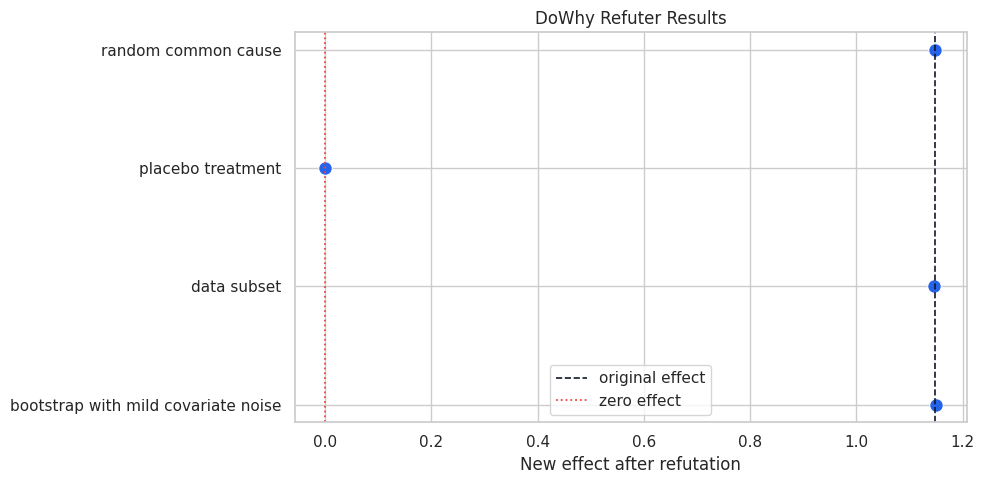

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_refuters = refutation_summary.copy()

sns.scatterplot(
    data=plot_refuters,
    x="new_effect",
    y="check",
    s=95,
    color="#2563eb",
    ax=ax,
)
ax.axvline(baseline_estimate.value, color="#111827", linestyle="--", linewidth=1.2, label="original effect")
ax.axvline(0, color="#ef4444", linestyle=":", linewidth=1.3, label="zero effect")
ax.set_title("DoWhy Refuter Results")
ax.set_xlabel("New effect after refutation")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_dowhy_refuter_results.png", dpi=160, bbox_inches="tight")
plt.show()

This plot should show three estimates near the original effect and the placebo estimate near zero. That visual separation is a healthy sign.

## Negative-Control Outcome Check

A negative-control outcome is an outcome the treatment should not plausibly affect. Here, `negative_control_outcome` is generated from the same confounders as the real outcome, but treatment has no causal effect on it.

If the adjusted treatment coefficient on this negative-control outcome is far from zero, the adjustment set may still be incomplete.

In [18]:
negative_control_models = {
    "negative control: naive": smf.ols(
        "negative_control_outcome ~ recommendation_exposure",
        data=refuter_df,
    ).fit(cov_type="HC1"),
    "negative control: omit pre_activity": smf.ols(
        "negative_control_outcome ~ recommendation_exposure + power_segment + account_age_z + seasonality_score",
        data=refuter_df,
    ).fit(cov_type="HC1"),
    "negative control: full adjustment": smf.ols(
        "negative_control_outcome ~ recommendation_exposure + pre_activity + power_segment + account_age_z + seasonality_score",
        data=refuter_df,
    ).fit(cov_type="HC1"),
}

negative_control_rows = []
for label, model in negative_control_models.items():
    conf_int = model.conf_int().loc[TREATMENT_COLUMN]
    negative_control_rows.append(
        {
            "model": label,
            "estimate": model.params[TREATMENT_COLUMN],
            "std_error": model.bse[TREATMENT_COLUMN],
            "ci_95_lower": conf_int[0],
            "ci_95_upper": conf_int[1],
            "target": 0.0,
            "absolute_distance_from_zero": abs(model.params[TREATMENT_COLUMN]),
        }
    )

negative_control_table = pd.DataFrame(negative_control_rows)
negative_control_table.to_csv(TABLE_DIR / "08_negative_control_outcome.csv", index=False)
display(negative_control_table)

,model,estimate,std_error,ci_95_lower,ci_95_upper,target,absolute_distance_from_zero
0,negative control: naive,0.6596,0.0411,0.5789,0.7402,0.0000,0.6596
1,negative control: omit pre_activity,0.4809,0.0400,0.4025,0.5593,0.0000,0.4809
2,negative control: full adjustment,0.0505,0.0346,-0.0173,0.1184,0.0000,0.0505


The naive negative-control effect is not near zero because treatment assignment is confounded. Full adjustment should pull it much closer to zero. The omitted-confounder version shows how a negative control can reveal residual confounding.

## Plot The Negative-Control Outcome Coefficients

This plot shows the treatment coefficient for the negative-control outcome under different adjustment choices. The target is zero.

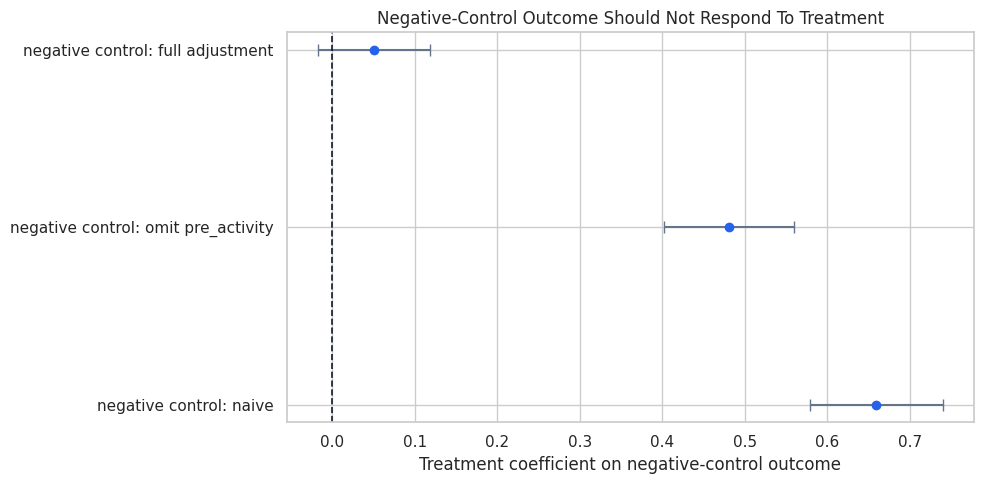

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_nc = negative_control_table.copy()
plot_nc["lower_error"] = plot_nc["estimate"] - plot_nc["ci_95_lower"]
plot_nc["upper_error"] = plot_nc["ci_95_upper"] - plot_nc["estimate"]

ax.errorbar(
    x=plot_nc["estimate"],
    y=plot_nc["model"],
    xerr=[plot_nc["lower_error"], plot_nc["upper_error"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.axvline(0, color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Negative-Control Outcome Should Not Respond To Treatment")
ax.set_xlabel("Treatment coefficient on negative-control outcome")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_negative_control_outcome_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()

The full-adjustment coefficient should be close to the zero line. The contrast with the naive and omitted-variable checks is the teaching point: negative controls are most useful when they can reveal a broken adjustment strategy.

## Placebo Exposure Check Outside DoWhy

The DoWhy placebo refuter already permuted treatment internally. This cell does the same idea manually with an explicit `placebo_exposure` column, then fits the adjusted outcome regression. The expected treatment coefficient is zero.

In [20]:
placebo_df = refuter_df.copy()
placebo_df["placebo_exposure"] = RNG.permutation(placebo_df[TREATMENT_COLUMN].to_numpy())

placebo_exposure_model = smf.ols(
    "weekly_value ~ placebo_exposure + pre_activity + power_segment + account_age_z + seasonality_score",
    data=placebo_df,
).fit(cov_type="HC1")
placebo_conf_int = placebo_exposure_model.conf_int().loc["placebo_exposure"]

placebo_exposure_table = pd.DataFrame(
    [
        {
            "model": "adjusted outcome model with placebo exposure",
            "estimate": placebo_exposure_model.params["placebo_exposure"],
            "std_error": placebo_exposure_model.bse["placebo_exposure"],
            "ci_95_lower": placebo_conf_int[0],
            "ci_95_upper": placebo_conf_int[1],
            "target": 0.0,
        }
    ]
)
placebo_exposure_table["absolute_distance_from_zero"] = placebo_exposure_table["estimate"].abs()

placebo_exposure_table.to_csv(TABLE_DIR / "08_manual_placebo_exposure.csv", index=False)
display(placebo_exposure_table)

,model,estimate,std_error,ci_95_lower,ci_95_upper,target,absolute_distance_from_zero
0,adjusted outcome model with placebo exposure,0.0513,0.0360,-0.0192,0.1219,0.0000,0.0513


The manual placebo exposure should have a small adjusted coefficient. This is the same causal idea as the DoWhy placebo refuter, shown in a form that is easy to inspect line by line.

## Omitted-Confounder Stress Test

A simple sensitivity check is to remove one observed confounder at a time and re-estimate the effect. This does not simulate hidden confounding directly, but it shows which observed variables have the most influence on the estimate.

In [21]:
def adjusted_formula_without(dropped_column=None):
    kept_confounders = [col for col in CONFONDER_COLUMNS if col != dropped_column]
    if kept_confounders:
        return "weekly_value ~ recommendation_exposure + " + " + ".join(kept_confounders)
    return "weekly_value ~ recommendation_exposure"

omitted_rows = []
for dropped_column in [None, *CONFONDER_COLUMNS]:
    label = "full adjustment" if dropped_column is None else f"drop {dropped_column}"
    model = smf.ols(adjusted_formula_without(dropped_column), data=refuter_df).fit(cov_type="HC1")
    conf_int = model.conf_int().loc[TREATMENT_COLUMN]
    omitted_rows.append(
        {
            "specification": label,
            "estimate": model.params[TREATMENT_COLUMN],
            "std_error": model.bse[TREATMENT_COLUMN],
            "ci_95_lower": conf_int[0],
            "ci_95_upper": conf_int[1],
            "target": true_effect,
            "error_vs_truth": model.params[TREATMENT_COLUMN] - true_effect,
        }
    )

omitted_confounder_table = pd.DataFrame(omitted_rows)
omitted_confounder_table.to_csv(TABLE_DIR / "08_omitted_confounder_stress_test.csv", index=False)
display(omitted_confounder_table)

,specification,estimate,std_error,ci_95_lower,ci_95_upper,target,error_vs_truth
0,full adjustment,1.1478,0.0338,1.0815,1.2140,1.2000,-0.0522
1,drop pre_activity,1.6608,0.0424,1.5777,1.7440,1.2000,0.4608
2,drop power_segment,1.2379,0.0355,1.1683,1.3075,1.2000,0.0379
3,drop account_age_z,1.2452,0.0360,1.1746,1.3158,1.2000,0.0452
4,drop seasonality_score,1.2737,0.0370,1.2011,1.3462,1.2000,0.0737


Dropping `pre_activity` should move the estimate the most because it is a strong driver of treatment and outcome. In real analyses, this style of check helps identify where measurement quality matters most.

## Plot The Omitted-Confounder Stress Test

The dashed line is the known true effect. Each point shows the treatment coefficient after dropping a different observed confounder.

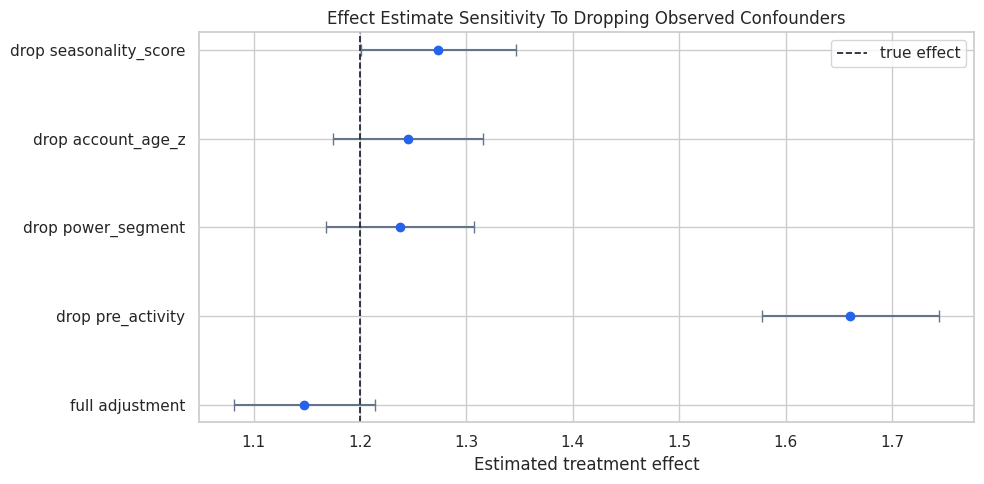

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_omit = omitted_confounder_table.copy()
plot_omit["lower_error"] = plot_omit["estimate"] - plot_omit["ci_95_lower"]
plot_omit["upper_error"] = plot_omit["ci_95_upper"] - plot_omit["estimate"]

ax.errorbar(
    x=plot_omit["estimate"],
    y=plot_omit["specification"],
    xerr=[plot_omit["lower_error"], plot_omit["upper_error"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.axvline(true_effect, color="#111827", linestyle="--", linewidth=1.2, label="true effect")
ax.set_title("Effect Estimate Sensitivity To Dropping Observed Confounders")
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_omitted_confounder_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()

The plot shows which observed variables anchor the adjustment. If a single measured variable strongly changes the result, an unmeasured variable with a similar role could also matter.

## Direct Hidden-Confounding Sensitivity With DoWhy

The next check asks a hypothetical question: what happens if there is an unobserved common cause that changes treatment assignment and the outcome?

We use DoWhy's `add_unobserved_common_cause` refuter with a grid of confounder strengths. Larger values mean a stronger hidden confounder. The result is not a proof that hidden confounding exists; it is a stress test for how quickly the estimate could move under different assumptions.

In [23]:
treatment_strength_grid = np.array([0.01, 0.03, 0.05, 0.08])
outcome_strength_grid = np.array([0.05, 0.15, 0.30])

hidden_confounder_refutation = refuter_model.refute_estimate(
    identified_estimand,
    baseline_estimate,
    method_name="add_unobserved_common_cause",
    simulation_method="direct-simulation",
    confounders_effect_on_treatment="binary_flip",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=treatment_strength_grid,
    effect_strength_on_outcome=outcome_strength_grid,
    plotmethod=None,
)

hidden_confounding_matrix = pd.DataFrame(
    hidden_confounder_refutation.new_effect_array,
    index=[f"treatment strength {value:.2f}" for value in treatment_strength_grid],
    columns=[f"outcome strength {value:.2f}" for value in outcome_strength_grid],
)

hidden_confounding_matrix.to_csv(TABLE_DIR / "08_hidden_confounding_sensitivity_matrix.csv")
display(hidden_confounding_matrix)
print(f"Original estimate: {baseline_estimate.value:.3f}")
print(f"Range after simulated hidden confounding: {hidden_confounder_refutation.new_effect}")

,outcome strength 0.05,outcome strength 0.15,outcome strength 0.30
treatment strength 0.01,1.1152,1.0944,1.0575
treatment strength 0.03,0.9898,0.9059,0.8491
treatment strength 0.05,0.7485,0.6583,0.5901
treatment strength 0.08,0.4757,0.4125,0.3318


Original estimate: 1.148
Range after simulated hidden confounding: (np.float64(0.3318400988946433), np.float64(1.1152246575277012))


The estimates shrink as the hypothetical hidden confounder becomes stronger. This table is useful because it translates an abstract concern into a concrete sensitivity range.

## Plot The Hidden-Confounding Sensitivity Matrix

A heatmap makes the sensitivity pattern easier to read. Darker cells mean the estimated effect has been pushed lower by stronger hypothetical confounding.

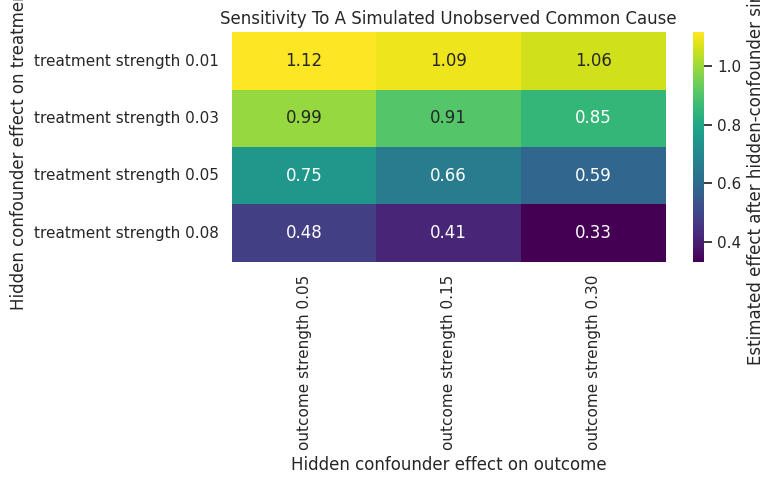

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    hidden_confounding_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Estimated effect after hidden-confounder simulation"},
    ax=ax,
)
ax.set_title("Sensitivity To A Simulated Unobserved Common Cause")
ax.set_xlabel("Hidden confounder effect on outcome")
ax.set_ylabel("Hidden confounder effect on treatment")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "08_hidden_confounding_sensitivity_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

The heatmap gives a compact stress-test story: weak hidden confounding leaves the estimate close to the original value, while stronger hidden confounding can materially reduce it.

## Bring All Checks Into One Credibility Table

The final summary table combines the core evidence from the notebook. It is written in plain language so it can be reused as a template for applied causal work.

In [25]:
credibility_rows = [
    {
        "check": "baseline adjusted estimate",
        "result": f"estimate {baseline_estimate.value:.3f} versus true effect {true_effect:.3f}",
        "causal reading": "adjustment recovers the known effect reasonably well in the teaching data",
    },
    {
        "check": "placebo treatment refuter",
        "result": f"placebo effect {placebo_treatment_refutation.new_effect:.3f}",
        "causal reading": "fake treatment does not reproduce the original effect",
    },
    {
        "check": "random common cause refuter",
        "result": f"new effect {random_common_cause_refutation.new_effect:.3f}",
        "causal reading": "adding random noise does not change the estimate materially",
    },
    {
        "check": "subset and bootstrap refuters",
        "result": f"subset {data_subset_refutation.new_effect:.3f}; bootstrap {bootstrap_refutation.new_effect:.3f}",
        "causal reading": "effect is stable under moderate sampling perturbations",
    },
    {
        "check": "negative-control outcome",
        "result": f"full-adjustment coefficient {negative_control_table.loc[negative_control_table['model'] == 'negative control: full adjustment', 'estimate'].iloc[0]:.3f}",
        "causal reading": "adjustment removes most of the treatment association with an outcome treatment should not affect",
    },
    {
        "check": "hidden-confounding sensitivity",
        "result": f"sensitivity range {hidden_confounder_refutation.new_effect[0]:.3f} to {hidden_confounder_refutation.new_effect[1]:.3f}",
        "causal reading": "strong hypothetical confounding could still reduce the estimate substantially",
    },
]

credibility_summary = pd.DataFrame(credibility_rows)
credibility_summary.to_csv(TABLE_DIR / "08_credibility_summary.csv", index=False)
display(credibility_summary)

,check,result,causal reading
0,baseline adjusted estimate,estimate 1.148 versus true effect 1.200,adjustment recovers the known effect reasonabl...
1,placebo treatment refuter,placebo effect 0.000,fake treatment does not reproduce the original...
2,random common cause refuter,new effect 1.148,adding random noise does not change the estima...
3,subset and bootstrap refuters,subset 1.146; bootstrap 1.151,effect is stable under moderate sampling pertu...
4,negative-control outcome,full-adjustment coefficient 0.051,adjustment removes most of the treatment assoc...
5,hidden-confounding sensitivity,sensitivity range 0.332 to 1.115,strong hypothetical confounding could still re...


The final row is the humility clause. The refuters support the estimate under the stated graph, but hidden confounding remains a design assumption that cannot be eliminated by diagnostics alone.

## Practical Refuter Checklist

When using these checks in a real analysis, keep the following habits:

- State the original causal estimand before showing refuters.
- Explain what each refuter is expected to do.
- Report the new effect, not only whether a check “passed.”
- Use negative controls that are substantively meaningful, not convenient random columns.
- Treat sensitivity analysis as a design conversation about plausible hidden causes.
- Remember that refuters cannot rescue a bad graph or post-treatment adjustment.

## Practice Prompts

Try these extensions after running the notebook:

1. Increase the effect of `pre_activity` on treatment assignment. Which checks become more sensitive?
2. Remove `pre_activity` from the DoWhy graph and rerun the refuters. Which checks reveal the problem most clearly?
3. Add a direct treatment effect to the negative-control outcome. What happens to the negative-control check?
4. Increase the hidden-confounding grid values. At what point does the estimated effect approach zero?
5. Write a short credibility memo with three paragraphs: estimate, refuter evidence, remaining assumptions.

## What Comes Next

The next tutorial moves to graph discovery and graph-level refutation. Here we assumed the graph was specified by the analyst. Next, we will explore tools that help learn or challenge graph structure from data, while keeping the same skepticism about what data alone can prove.